## This notebook integrates two AI agents:
1. **Rule Extraction Agent**: Extracts SBVR rules from new policy documents
2. **MCP GitHub Agent**: Fetches current rule configuration from GitHub and performs impact analysis

## Prerequisites:
1. GitHub Personal Access Token (for MCP GitHub integration)
2. OpenAI API Key
3. A GitHub repository with current policy rules configuration

In [1]:
import os
import re
import json
from typing import TypedDict, List, Annotated, Dict, Any
import operator

from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

# LangChain MCP Adapter for GitHub integration
from langchain_mcp_adapters.client import MultiServerMCPClient


c:\Users\User\anaconda3\envs\graphrag\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Define Enhanced State

Compared to the original agent, we need to track more information throughout the workflow:

In [2]:
class PolicyImpactAnalysisState(TypedDict):
    """Enhanced state for multi-workflow routing system"""
    # Conversation history
    messages: Annotated[List[BaseMessage], operator.add]
    
    # Current rules from GitHub repository (used in Impact Analysis workflow)
    current_rules: List[Dict[str, Any]]
    
    # New extracted rules from latest policy documents (used in Workflow 4)
    new_rules: List[Dict[str, Any]]
    
    # Impact analysis report (used in Impact Analysis workflow)
    impact_report: str
    
    # Workflow routing flag - which workflow to execute
    workflow_type: str  # "rule_extraction" | "impact_analysis" | "qa" | "impact_and_update"
    
    # User's original query
    user_query: str

    # SHA of the current file in the GitHub repository
    current_file_sha: str

## 2. Build the Toolbox

### Tool 1 & 2: Original SBVR Extraction and General QA Tools

In [3]:
# Import from the same directory (Agent 1)
from localsearch_engine_builder import build_search_engine

# Configure paths - adjusted for Agent 1 folder
INDEX_ROOT = os.path.join("..", "kyc_workflow", "output")
QA_PROMPT_PATH = "cust_local_search_system_prompt.txt"
SBVR_PROMPT_PATH = "sbvr_local_search_system_prompt.txt"
IMPACT_ANALYSIS_PROMPT_PATH = "impact_analysis_system_prompt.txt"

# Build SBVR extraction engine
print("🔧 Building SBVR Extraction engine...")
sbvr_engine = build_search_engine(
    index_root=INDEX_ROOT,
    system_prompt_path=SBVR_PROMPT_PATH,
    response_type="Return SBVR-style business rules in strict JSON format."
)

# Build general QA engine
print("🔧 Building General QA engine...")
qa_engine = build_search_engine(
    index_root=INDEX_ROOT,
    system_prompt_path=QA_PROMPT_PATH,
    response_type="multiple paragraphs"
)

print("🔧 Building Impact detect engine...")
impact_engine = build_search_engine(
    index_root=INDEX_ROOT,
    system_prompt_path=IMPACT_ANALYSIS_PROMPT_PATH,
    response_type="Return validation result in strict JSON format."
)
print("✅ Search engines ready!")

🔧 Building SBVR Extraction engine...
🔧 Building General QA engine...
🔧 Building Impact detect engine...
✅ Search engines ready!


In [4]:
@tool
async def sbvr_extraction(question: str) -> str:
    """
    Extract SBVR-formatted rules from policy documents.
    Use this when user asks to "extract rules", "find obligations", "list requirements", etc.
    
    Args:
        question: Question about rule extraction
    
    Returns:
        JSON string containing list of rules
    """
    print("🔍 Executing SBVR rule extraction...")
    try:
        result = await sbvr_engine.search(question)
        return result.response  # Return JSON string
    except Exception as e:
        return json.dumps({"error": str(e), "rules": []})

@tool
async def general_qa(question: str) -> str:
    """
    Answer general questions about policies.
    Suitable for definitions, summaries, background information, etc.
    """
    print("💬 Executing general Q&A...")
    try:
        result = await qa_engine.search(question)
        return result.response
    except Exception as e:
        return f"Error: {e}"

### Tool 3: GitHub MCP Integration (LangChain Adapter - HTTP Transport)

**Using LangChain MCP Adapter with HTTP Transport** to connect to GitHub's cloud MCP service.

In [5]:
# Initialize MCP Client for GitHub using LangChain Adapter
print("🔧 Initializing MCP GitHub Client with LangChain Adapter...")

async def initialize_mcp_github_client():
    """Initialize MCP client using LangChain adapter and return GitHub tools"""
    github_token = os.environ.get("GITHUB_PERSONAL_ACCESS_TOKEN", "")
    
    if not github_token:
        print("⚠️ Warning: GITHUB_PERSONAL_ACCESS_TOKEN not set")
        return None, []
    
    try:
        # Configure MCP client with GitHub server (HTTP Transport)
        print("🔌 Connecting to GitHub MCP Cloud Service (HTTP)...")
        client = MultiServerMCPClient({
            "github": {
                "transport": "http",
                "url": "https://api.githubcopilot.com/mcp/",
                "headers": {
                    "Authorization": f"Bearer {github_token}"
                }
            }
        })
        
        # Get all available GitHub tools (auto-discovery)
        tools = await client.get_tools()
        print(f"✅ MCP GitHub Client initialized with {len(tools)} tools available")
        
        # List available tools
        print("📋 Available GitHub tools:")
        for tool in tools:
            print(f"   - {tool.name}")
        
        return client, tools
    except Exception as e:
        print(f"❌ Failed to initialize MCP client: {e}")
        return None, []

# Initialize and get GitHub tools
mcp_client_result = await initialize_mcp_github_client()
print(mcp_client_result)
if mcp_client_result:
    mcp_github_client, github_mcp_tools = mcp_client_result
    # Find the get_file_contents tool
    github_read_file_tool = next(
        (t for t in github_mcp_tools if t.name == "get_file_contents"), 
        None
    )
    if github_read_file_tool:
        print(f"✅ Found GitHub file reading tool: {github_read_file_tool.name}")
    else:
        print("⚠️ get_file_contents tool not found in available tools")
else:
    mcp_github_client = None
    github_mcp_tools = []
    github_read_file_tool = None
    print("⚠️ GitHub MCP tools not available")

# Create a wrapper tool for our specific use case

@tool
async def fetch_current_policy_rules(owner: str, repo: str, file_path: str, branch: str = "main") -> Dict[str, Any]:
    """
    Fetch current policy rules configuration from GitHub repository using MCP Adapter.
    Returns a dictionary to update the graph's state, including the file's SHA.
    
    Args:
        owner: GitHub repository owner
        repo: Repository name
        file_path: Path to the rule configuration file
        branch: Branch name (default: main)
    
    Returns:
        Dictionary with:
        - 'current_rules': List of rules
        - 'current_file_sha': SHA of the fetched file (for safe updates)
        - 'error': Error message if failed
    """
    print(f"📥 Fetching current rules from GitHub: {owner}/{repo}/{file_path}")
    
    try:
        if not github_read_file_tool:
            raise Exception("GitHub MCP tools not initialized.")
        
        # Use the MCP tool to read file
        result = await github_read_file_tool.ainvoke({
            "owner": owner,
            "repo": repo,
            "path": file_path,
            "branch": branch
        })

        print(f"🔍 MCP Response Type: {type(result)}, Length: {len(result) if isinstance(result, list) else 'N/A'}")
        
        # Extract both content AND SHA from MCP response
        content = None
        file_sha = None
        
        if isinstance(result, list):
            for item in result:
                if isinstance(item, dict) and item.get('type') == 'text':
                    text = item.get('text', '')
                    
                    # 🔍 Check if this is the status message containing SHA
                    if 'successfully downloaded' in text.lower() and 'SHA:' in text:
                        # Extract SHA from status message using regex
                        sha_match = re.search(r'SHA:\s*([a-f0-9]{40})', text, re.IGNORECASE)
                        if sha_match:
                            file_sha = sha_match.group(1)
                            print(f"✅ Extracted SHA from status message: {file_sha}")
                    
                    # 🔍 Check if this is the actual JSON content
                    elif text.strip().startswith('{') or text.strip().startswith('['):
                        content = text
                        print(f"✅ Found JSON content ({len(content)} characters)")
        
        # Validate we got both SHA and content
        if not content:
            raise Exception("Could not extract file content from MCP response")
        
       
        print(f"✅ Successfully fetched {len(content)} characters from GitHub")
        if file_sha:
            print(f"🔑 File SHA: {file_sha}")
        
        # Parse rules from JSON content
        rules_data = json.loads(content)
        current_rules = rules_data if isinstance(rules_data, list) else rules_data.get("rules", [])
        
        return {
            "current_rules": current_rules,
            "current_file_sha": file_sha or "",
            "error": None
        }
                    
    except json.JSONDecodeError as e:
        error_msg = f"Failed to parse JSON from GitHub: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "current_rules": [],
            "current_file_sha": "",
            "error": error_msg
        }
    except Exception as e:
        error_msg = f"Failed to fetch from GitHub: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "current_rules": [],
            "current_file_sha": "",
            "error": error_msg
        }

print("✅ fetch_current_policy_rules updated - Improved SHA and content extraction")

🔧 Initializing MCP GitHub Client with LangChain Adapter...
🔌 Connecting to GitHub MCP Cloud Service (HTTP)...
✅ MCP GitHub Client initialized with 40 tools available
📋 Available GitHub tools:
   - add_comment_to_pending_review
   - add_issue_comment
   - assign_copilot_to_issue
   - create_branch
   - create_or_update_file
   - create_pull_request
   - create_repository
   - delete_file
   - fork_repository
   - get_commit
   - get_file_contents
   - get_label
   - get_latest_release
   - get_me
   - get_release_by_tag
   - get_tag
   - get_team_members
   - get_teams
   - issue_read
   - issue_write
   - list_branches
   - list_commits
   - list_issue_types
   - list_issues
   - list_pull_requests
   - list_releases
   - list_tags
   - merge_pull_request
   - pull_request_read
   - pull_request_review_write
   - push_files
   - request_copilot_review
   - search_code
   - search_issues
   - search_pull_requests
   - search_repositories
   - search_users
   - sub_issue_write
   - updat

### Tool 4: Impact Analysis (Core Functionality)

In [6]:
@tool
async def analyze_policy_impact(rules: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Analyze policy impact by validating each rule individually against latest documents.
    Uses the global impact_engine for per-rule validation.
    Returns structured JSON format for easier downstream processing.
    
    Args:
        rules: List of rule dictionaries from the graph's state
    
    Returns:
        Dictionary with 'impact_report' key containing JSON string of analysis results
    """
    print("📊 Executing per-rule impact analysis...")
    
    try:
        current_rules = rules
        
        if not current_rules:
            return {"impact_report": json.dumps({"error": "No current rules provided"})}
        
        rule_count = len(current_rules)
        print(f"📥 Loaded {rule_count} current rules for analysis")
        
        # Load the per-rule validation prompt template
        PER_RULE_PROMPT_PATH = "per_rule_validation_prompt.txt"
        with open(PER_RULE_PROMPT_PATH, "r", encoding="utf-8") as f:
            per_rule_prompt_template = f.read()
        
        # Process each rule individually
        validation_results = []
        
        for idx, rule in enumerate(current_rules, 1):
            rule_id = rule.get("id", f"UNKNOWN-{idx}")
            print(f"\n🔍 [{idx}/{rule_count}] Validating rule: {rule_id}")
            
            # Format the query for this specific rule
            rule_query = per_rule_prompt_template.format(
                rule_json=json.dumps(rule, ensure_ascii=False, indent=2)
            )
            
            # Execute validation query using global impact_engine
            try:
                result = await impact_engine.search(rule_query)
                
                # Parse the JSON response
                try:
                    validation_data = json.loads(result.response)
                    validation_results.append({
                        "rule_id": rule_id,
                        "analysis": validation_data,
                        "success": True
                    })
                    print(f"✅ Rule {rule_id} validated (status: {validation_data.get('status', 'UNKNOWN')})")
                except json.JSONDecodeError:
                    # Fallback if response is not valid JSON
                    validation_results.append({
                        "rule_id": rule_id,
                        "analysis": {"error": "Invalid JSON response", "raw_response": result.response},
                        "success": False
                    })
                    print(f"⚠️ Rule {rule_id}: JSON parsing error")
                    
            except Exception as e:
                print(f"❌ Error validating {rule_id}: {e}")
                validation_results.append({
                    "rule_id": rule_id,
                    "analysis": {"error": str(e)},
                    "success": False
                })
        
        # Generate consolidated JSON report
        print("\n📋 Generating consolidated impact analysis report (JSON format)...")
        
        final_report = {
            "total_rules_analyzed": rule_count,
            "rules_analysis": validation_results
        }
        
        # Convert to JSON string
        report_json = json.dumps(final_report, ensure_ascii=False, indent=2)
        
        print(f"✅ Impact analysis complete for {rule_count} rules")
        
        # Return as state update dictionary
        return {"impact_report": report_json}
            
    except Exception as e:
        error_msg = f"Error: Impact analysis failed. Details: {str(e)}"
        print(f"❌ {error_msg}")
        return {"impact_report": json.dumps({"error": error_msg})}

print("✅ Enhanced per-rule analyze_policy_impact tool redefined - Returns JSON format")

✅ Enhanced per-rule analyze_policy_impact tool redefined - Returns JSON format


## 3. Multi-Workflow Routing System

### Router Node 

In [7]:
# Initialize LLM for routing
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def router_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Router node: Analyze user intent and decide which workflow to execute.
    
    This node uses LLM to classify the user's query into one of four workflows:
    1. rule_extraction: Extract SBVR rules from policy documents (no GitHub update)
    2. impact_analysis: Fetch current rules from GitHub and analyze impact (no update)
    3. qa: Answer general questions about policies
    4. impact_and_update: Analyze impact AND update GitHub with new rules
    """
    print("\n" + "="*60)
    print("🧭 ROUTER: Analyzing user intent...")
    print("="*60)
    
    messages = state["messages"]
    user_query = messages[-1].content if messages else ""
    
    # Create a classification prompt
    classification_prompt = f"""You are a workflow router. Analyze the user's query and classify it into ONE of these workflows:

1. **rule_extraction**: User wants to extract SBVR-formatted business rules from policy documents WITHOUT updating GitHub.
   - Keywords: "extract rules", "find obligations", "list requirements", "SBVR", "business rules"
   
2. **impact_analysis**: User wants to analyze the impact of policy changes WITHOUT updating GitHub.
   - Keywords: "impact analysis", "compare rules", "validate rules", "check changes", "policy impact"
   
3. **qa**: User has general questions about policies, definitions, or background information.
   - Keywords: "what is", "explain", "define", "tell me about", "summarize"

4. **impact_and_update**: User wants to analyze impact AND update GitHub repository with new rules based on latest policy documents.
   - Keywords: "update rules", "sync rules", "refresh policy", "update GitHub", "commit changes", "push new rules"

User Query: "{user_query}"

Respond with ONLY ONE WORD: rule_extraction, impact_analysis, qa, or impact_and_update"""

    response = llm.invoke([HumanMessage(content=classification_prompt)])
    workflow_type = response.content.strip().lower()
    
    # Validate the response
    valid_workflows = ["rule_extraction", "impact_analysis", "qa", "impact_and_update"]
    if workflow_type not in valid_workflows:
        workflow_type = "qa"  # Default to QA if classification fails
    
    print(f"✅ Detected workflow: {workflow_type.upper()}")
    
    return {
        "workflow_type": workflow_type,
        "user_query": user_query
    }

print("✅ router_node defined")

✅ router_node defined


### Workflow 1: SBVR Rule Extraction

In [8]:
async def rule_extraction_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 1: Extract SBVR rules from policy documents.
    This node calls the sbvr_extraction tool with the user's query.
    """
    print("\n" + "="*60)
    print("📋 WORKFLOW 1: SBVR Rule Extraction")
    print("="*60)
    
    user_query = state.get("user_query", "")
    
    # Call the SBVR extraction tool
    result = await sbvr_extraction.ainvoke({"question": user_query})
    
    # Format the response
    response_message = f"""✅ **SBVR Rule Extraction Complete**

{result}
"""
    
    print("✅ Rule extraction completed")
    
    return {
        "messages": [AIMessage(content=response_message)]
    }

print("✅ rule_extraction_node defined")

✅ rule_extraction_node defined


### Workflow 2: Impact Analysis (Step 1 - Fetch Rules)

In [9]:
async def impact_analysis_fetch_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 2 - Step 1: Fetch current rules from GitHub.
    Now also extracts and stores the file SHA for later updates.
    """
    print("\n" + "="*60)
    print("📥 WORKFLOW 2 - STEP 1: Fetching Rules from GitHub")
    print("="*60)
    
    owner = "JJchan123"
    repo = "compliance_rule_configuration"
    file_path = "policy_rules.json"
    branch = "main"
    
    result = await fetch_current_policy_rules.ainvoke({
        "owner": owner,
        "repo": repo,
        "file_path": file_path,
        "branch": branch
    })
    
    if result.get("error"):
        error_msg = f"❌ Failed to fetch rules: {result['error']}"
        print(error_msg)
        return {
            "messages": [AIMessage(content=error_msg)],
            "current_rules": [],
            "current_file_sha": ""
        }
    
    fetched_rules = result.get("current_rules", [])
    fetched_sha = result.get("current_file_sha", "")
    
    print(f"✅ Successfully fetched {len(fetched_rules)} rules from GitHub")
    if fetched_sha:
        print(f"🔑 Stored file SHA in state: {fetched_sha}")
    else:
        print(f"⚠️ Warning: No SHA available (update might fail)")
    
    return {
        "current_rules": fetched_rules,
        "current_file_sha": fetched_sha
    }

print("✅ impact_analysis_fetch_node updated - Now stores SHA in state")

✅ impact_analysis_fetch_node updated - Now stores SHA in state


### Workflow 2: Impact Analysis (Step 2 - Current Rule(mcp) vs Latest Rule(Knowledge Graph))

In [10]:
async def impact_analysis_analyze_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 2 - Step 2: Analyze the impact of current rules.
    This node calls analyze_policy_impact with rules from the state.
    """
    print("\n" + "="*60)
    print("📊 WORKFLOW 2 - STEP 2: Analyzing Policy Impact")
    print("="*60)
    
    current_rules = state.get("current_rules", [])
    
    # Check if we have rules to analyze
    if not current_rules:
        error_msg = "⚠️ Cannot analyze impact: no rules were fetched in previous step."
        print(error_msg)
        return {
            "impact_report": "Error: No rules available for analysis.",
            "messages": [AIMessage(content=error_msg)]
        }
    
    # Call the analysis tool
    result = await analyze_policy_impact.ainvoke({"rules": current_rules})
    
    report = result.get("impact_report", "")
    
    # Format the final response
    final_message = f"""✅ **Impact Analysis Complete**

{report}

---
**Total Rules Analyzed**: {len(current_rules)}
"""
    
    print(f"✅ Impact analysis completed for {len(current_rules)} rules")
    
    # Update state with analysis report
    return {
        "impact_report": report,
        "messages": [AIMessage(content=final_message)]
    }

print("✅ impact_analysis_analyze_node defined")

✅ impact_analysis_analyze_node defined


### Workflow 3: General QA 

In [11]:
async def qa_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 3: Answer general questions about policies.
    This node calls the general_qa tool with the user's query.
    """
    print("\n" + "="*60)
    print("💬 WORKFLOW 3: General Q&A")
    print("="*60)
    
    user_query = state.get("user_query", "")
    
    # Call the QA tool
    result = await general_qa.ainvoke({"question": user_query})
    
    # Format the response
    response_message = f"""✅ **Answer**

{result}
"""
    
    print("✅ Q&A completed")
    
    return {
        "messages": [AIMessage(content=response_message)]
    }

print("✅ qa_node defined")

✅ qa_node defined


### Workflow 4: Impact & Update - Extract New Rules

In [12]:
async def extract_new_rules_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 4 - Step 3: Extract and update rules one by one based on impact analysis.
    Uses current_rules and impact_report (JSON format) as context.
    Outputs new_rules in the exact same format as current_rules.
    """
    print("\n" + "="*60)
    print("📋 WORKFLOW 4 - STEP 3: Extracting and Updating Rules (Per-Rule Processing)")
    print("="*60)
    
    current_rules = state.get("current_rules", [])
    impact_report_json = state.get("impact_report", "")
    
    # Validation checks
    if not current_rules:
        error_msg = "⚠️ No current rules available. Cannot extract new rules without baseline."
        print(error_msg)
        return {
            "new_rules": [],
            "messages": [AIMessage(content=error_msg)]
        }
    
    if not impact_report_json:
        error_msg = "⚠️ No impact report available. Cannot update rules without impact analysis."
        print(error_msg)
        return {
            "new_rules": [],
            "messages": [AIMessage(content=error_msg)]
        }
    
    # Parse the JSON impact report
    try:
        impact_report = json.loads(impact_report_json)
        rules_analysis = impact_report.get("rules_analysis", [])
    except json.JSONDecodeError as e:
        error_msg = f"❌ Failed to parse impact report JSON: {str(e)}"
        print(error_msg)
        return {
            "new_rules": [],
            "messages": [AIMessage(content=error_msg)]
        }
    
    # Build analysis mapping
    print(f"\n🔍 Debug: Total rules in analysis: {len(rules_analysis)}")
    
    analysis_map = {}
    for item in rules_analysis:
        if item.get("success"):
            rule_id = item.get("rule_id")
            analysis = item.get("analysis", {})
            analysis_map[rule_id] = analysis
            print(f"   ✓ Mapped {rule_id}: status={analysis.get('status', 'UNKNOWN')}")
        else:
            print(f"   ✗ Skipped {item.get('rule_id')}: validation failed")
    
    rule_count = len(current_rules)
    print(f"\n📥 Processing {rule_count} rules for update based on impact analysis")
    print(f"📊 Impact analysis available for {len(analysis_map)} rules")
    
    # If no analysis available, return error
    if len(analysis_map) == 0:
        error_msg = "❌ No valid impact analysis available. Cannot proceed with rule updates."
        print(error_msg)
        return {
            "new_rules": [],
            "messages": [AIMessage(content=error_msg)]
        }
    
    # Load the per-rule update prompt template
    PER_RULE_UPDATE_PROMPT_PATH = "per_rule_update_prompt.txt"
    
    with open(PER_RULE_UPDATE_PROMPT_PATH, "r", encoding="utf-8") as f:
        per_rule_update_template = f.read()
    
    # Process each rule individually
    updated_rules = []
    stats = {
        "unchanged": 0,
        "modified": 0,
        "deleted": 0,      # 🔧 Changed from "deprecated" to "deleted"
        "errors": 0
    }
    
    for idx, rule in enumerate(current_rules, 1):
        rule_id = rule.get("id", f"UNKNOWN-{idx}")
        print(f"\n🔍 [{idx}/{rule_count}] Processing rule: {rule_id}")
        
        # Get the impact analysis for this specific rule
        rule_analysis = analysis_map.get(rule_id, {})
        
        if not rule_analysis:
            print(f"⚠️ No impact analysis found for {rule_id}, keeping original rule")
            updated_rules.append(rule)
            stats["errors"] += 1
            continue
        
        # Check status to decide processing strategy
        status = rule_analysis.get("status", "UNKNOWN")
        print(f"   Status: {status}")
        
        # 🔧 Handle UNCHANGED - keep original rule
        if status == "UNCHANGED":
            print(f"✅ Rule {rule_id} unchanged, keeping original")
            updated_rules.append(rule)
            stats["unchanged"] += 1
            continue
        
        # 🔧 Handle DELETED - skip this rule (don't add to updated_rules)
        if status == "DELETED":
            print(f"🗑️  Rule {rule_id} deleted from latest policy, removing from config")
            stats["deleted"] += 1
            continue  # Don't append to updated_rules
        
        # 🔧 Handle MODIFIED - query SBVR engine for updated rule
        if status == "MODIFIED":
            rule_update_query = per_rule_update_template.format(
                current_rule_json=json.dumps(rule, ensure_ascii=False, indent=2),
                impact_analysis_json=json.dumps(rule_analysis, ensure_ascii=False, indent=2)
            )
            
            # Execute update query using sbvr_engine
            try:
                result = await sbvr_engine.search(rule_update_query)
                
                # Parse the result
                try:
                    updated_rule = json.loads(result.response)
                    
                    # Validate that it's a proper rule object with required fields
                    required_fields = ["id", "subject", "modality", "action"]
                    if all(field in updated_rule for field in required_fields):
                        # Ensure the rule ID matches
                        updated_rule["id"] = rule_id
                        
                        updated_rules.append(updated_rule)
                        stats["modified"] += 1
                        
                        print(f"✅ Rule {rule_id} updated successfully")
                    else:
                        # Missing required fields, keep original
                        print(f"⚠️ Rule {rule_id}: Updated rule missing required fields, keeping original")
                        updated_rules.append(rule)
                        stats["errors"] += 1
                        
                except json.JSONDecodeError as e:
                    print(f"⚠️ Rule {rule_id}: JSON parsing error ({e}), keeping original")
                    updated_rules.append(rule)
                    stats["errors"] += 1
                    
            except Exception as e:
                print(f"❌ Error updating rule {rule_id}: {e}")
                # On error, keep the original rule
                updated_rules.append(rule)
                stats["errors"] += 1
        else:
            # Unknown status - keep original
            print(f"⚠️ Unknown status '{status}' for {rule_id}, keeping original")
            updated_rules.append(rule)
            stats["errors"] += 1
    
    # Generate summary
    print(f"\n📋 Update Summary:")
    print(f"   Total rules processed: {rule_count}")
    print(f"   Unchanged: {stats['unchanged']}")
    print(f"   Modified: {stats['modified']}")
    print(f"   Deleted: {stats['deleted']}")           # 🔧 Changed label

    print(f"   Final rules count: {len(updated_rules)}")  # 🔧 Added final count
    
    summary_message = f"""✅ **Rule Update Complete**

**Processing Summary:**
- Total rules processed: {rule_count}
- Unchanged: {stats['unchanged']}
- Modified: {stats['modified']}
- Deleted: {stats['deleted']}
- **Final rules count: {len(updated_rules)}**

**Processing Method:**
Each rule was individually analyzed using:
1. Current rule configuration from GitHub
2. Structured impact analysis (JSON format)
3. SBVR extraction engine for format consistency

All rules maintain the exact same JSON structure and are ready for GitHub update.
"""
    
    # Update state with new rules
    return {
        "new_rules": updated_rules,
        "messages": [AIMessage(content=summary_message)]
    }

print("✅ extract_new_rules_node redefined - Fixed status handling (UNCHANGED|MODIFIED|DELETED)")

✅ extract_new_rules_node redefined - Fixed status handling (UNCHANGED|MODIFIED|DELETED)


### Workflow 4: Impact & Update - Update to GitHub using LLM Agent

In [13]:
async def github_update_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 4 - Step 4: Update GitHub repository with new rules.
    Uses DIRECT MCP tool invocation (bypasses ToolNode to avoid config issues).
    """
    print("\n" + "="*60)
    print("📤 WORKFLOW 4 - STEP 4: Updating GitHub Repository")
    print("="*60)
    
    new_rules = state.get("new_rules", [])
    current_sha = state.get("current_file_sha", "")
    
    if not new_rules:
        error_msg = "⚠️ No new rules to update."
        print(error_msg)
        return {"messages": [AIMessage(content=error_msg)]}
    
    owner = "JJchan123"
    repo = "compliance_rule_configuration"
    file_path = "policy_rules.json"
    branch = "main"
    
    new_content = json.dumps({"rules": new_rules}, indent=2, ensure_ascii=False)
    rule_count = len(new_rules)
    print(new_content)

    print(f"📝 Preparing to update {file_path} with {rule_count} rules")
    
    if current_sha:
        print(f"🔑 Using SHA from state: {current_sha}")
    else:
        print(f"⚠️ No SHA available - update might fail if file exists")
    
    # 🔧 FIX: Direct MCP tool invocation instead of ToolNode
    # Find the create_or_update_file tool
    github_write_tool = next(
        (t for t in github_mcp_tools if t.name == "create_or_update_file"),
        None
    )
    
    if not github_write_tool:
        error_msg = "❌ create_or_update_file tool not available"
        print(error_msg)
        print(f"   Available tools: {[t.name for t in github_mcp_tools]}")
        return {"messages": [AIMessage(content=error_msg)]}
    
    print(f"✅ Found GitHub write tool: {github_write_tool.name}")
    
    # Manually construct tool parameters
    tool_params = {
        "owner": owner,
        "repo": repo,
        "path": file_path,
        "content": new_content,
        "message": f"Update policy rules - {rule_count} rules updated",
        "branch": branch
    }
    
    # Add SHA if available
    if current_sha:
        tool_params["sha"] = current_sha
        print(f"✅ SHA included in parameters")
    
    try:
        print(f"🚀 Executing direct MCP tool invocation...")
        print(f"   Parameters: {list(tool_params.keys())}")
        
        # 🔧 Direct invocation - bypasses ToolNode
        result = await github_write_tool.ainvoke(tool_params)
        
        print(f"✅ MCP tool executed successfully")
        print(f"   Result type: {type(result)}")
        
        # Parse MCP response
        commit_sha = None
        commit_url = None
        
        # MCP tools may return list of dicts or string
        if isinstance(result, list):
            for item in result:
                if isinstance(item, dict):
                    text = item.get('text', '')
                    
                    # Extract commit SHA from response
                    sha_match = re.search(r'commit.*?([a-f0-9]{40})', text, re.IGNORECASE)
                    if sha_match:
                        commit_sha = sha_match.group(1)
                    
                    # Extract URL if available
                    url_match = re.search(r'(https://github\.com/[^\s]+)', text)
                    if url_match:
                        commit_url = url_match.group(1)
                        
        elif isinstance(result, str):
            commit_sha_match = re.search(r'commit.*?([a-f0-9]{40})', result, re.IGNORECASE)
            if commit_sha_match:
                commit_sha = commit_sha_match.group(1)
            
            url_match = re.search(r'(https://github\.com/[^\s]+)', result)
            if url_match:
                commit_url = url_match.group(1)
        
        # Format success message
        success_msg = f"""✅ **GitHub Update Successful**

**Repository**: {owner}/{repo}
**File**: {file_path}
**Branch**: {branch}
**Rules Updated**: {rule_count}
**SHA Used**: {current_sha or 'N/A'}
"""
        
        if commit_sha:
            success_msg += f"\n**New Commit SHA**: {commit_sha}"
        
        if commit_url:
            success_msg += f"\n**Commit URL**: {commit_url}"
        
        success_msg += f"\n\n**Update Method**: Direct MCP tool invocation (bypassed ToolNode)"
        
        print("✅ GitHub update completed successfully")
        
        return {"messages": [AIMessage(content=success_msg)]}
            
    except Exception as e:
        error_msg = f"❌ GitHub update failed: {str(e)}"
        print(error_msg)
        
        # Print full traceback for debugging
        import traceback
        print("\n🔍 Full Error Traceback:")
        print(traceback.format_exc())
        
        return {"messages": [AIMessage(content=error_msg)]}


## 4. Build Routed Workflow Graph (with Workflow 4)

In [14]:
# Define routing function
def route_workflow(state: PolicyImpactAnalysisState) -> str:
    """
    Routing function: Decide which workflow to execute based on router's classification.
    """
    workflow_type = state.get("workflow_type", "qa")
    print(f"🔀 Routing to: {workflow_type}")
    return workflow_type

# Define conditional routing after impact analysis
def should_update_rules(state: PolicyImpactAnalysisState) -> str:
    """
    Decide whether to update GitHub rules after impact analysis.
    Only proceed to update if workflow type is 'impact_and_update'.
    """
    workflow_type = state.get("workflow_type", "")
    
    if workflow_type == "impact_and_update":
        print("➡️ Proceeding to extract and update rules")
        return "extract_new_rules"
    else:
        print("➡️ Impact analysis complete, ending workflow")
        return "end"

# Create state graph
workflow = StateGraph(PolicyImpactAnalysisState)

# Add all nodes
workflow.add_node("router", router_node)
workflow.add_node("rule_extraction", rule_extraction_node)
workflow.add_node("impact_analysis_fetch", impact_analysis_fetch_node)
workflow.add_node("impact_analysis_analyze", impact_analysis_analyze_node)
workflow.add_node("qa", qa_node)
workflow.add_node("extract_new_rules", extract_new_rules_node)
workflow.add_node("github_update", github_update_node)

# Define workflow structure
# START -> Router -> One of four workflows
workflow.add_edge(START, "router")

# Conditional routing based on workflow_type
workflow.add_conditional_edges(
    "router",
    route_workflow,
    {
        "rule_extraction": "rule_extraction",
        "impact_analysis": "impact_analysis_fetch",
        "qa": "qa",
        "impact_and_update": "impact_analysis_fetch"  # Start with impact analysis
    }
)

# Workflow 1: Rule extraction goes directly to END
workflow.add_edge("rule_extraction", END)

# Workflow 2 & 4: Impact analysis (shared path)
workflow.add_edge("impact_analysis_fetch", "impact_analysis_analyze")

# Conditional edge: After impact analysis, decide whether to update GitHub
workflow.add_conditional_edges(
    "impact_analysis_analyze",
    should_update_rules,
    {
        "extract_new_rules": "extract_new_rules",  # Workflow 4: Continue to update
        "end": END  # Workflow 2: End here
    }
)

# Workflow 4 continuation: Extract new rules then update GitHub
workflow.add_edge("extract_new_rules", "github_update")
workflow.add_edge("github_update", END)

# Workflow 3: QA goes directly to END
workflow.add_edge("qa", END)

# Compile the graph
app = workflow.compile()

print("✅ Multi-workflow routing graph built successfully!")
print("\n📊 Workflow Structure:")
print("   START → router → [rule_extraction → END]")
print("                  → [impact_analysis_fetch → impact_analysis_analyze → END]")
print("                  → [impact_analysis_fetch → impact_analysis_analyze → extract_new_rules → github_update → END]")
print("                  → [qa → END]")
print("\n🎯 Four workflows available: rule_extraction, impact_analysis, impact_and_update, qa")

✅ Multi-workflow routing graph built successfully!

📊 Workflow Structure:
   START → router → [rule_extraction → END]
                  → [impact_analysis_fetch → impact_analysis_analyze → END]
                  → [impact_analysis_fetch → impact_analysis_analyze → extract_new_rules → github_update → END]
                  → [qa → END]

🎯 Four workflows available: rule_extraction, impact_analysis, impact_and_update, qa


## 5. Visualize Multi-Workflow Graph

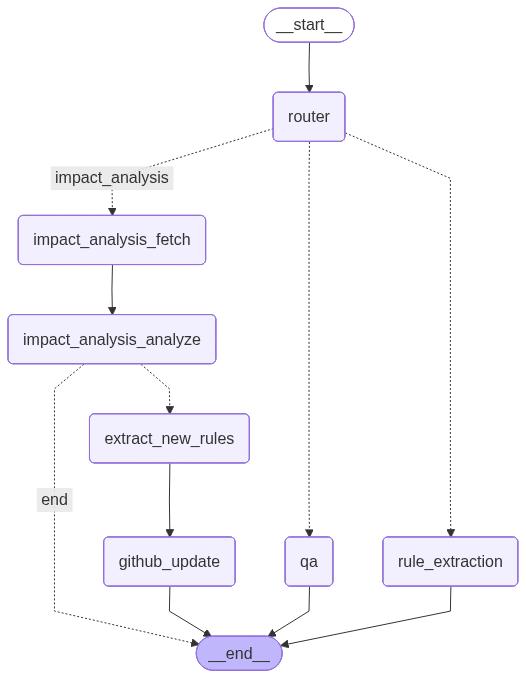

In [15]:
# Visualize graph structure if you have graphviz installed
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Cannot generate graph (graphviz required): {e}")

## 6. Run Multi-Workflow System

In [16]:
async def run_workflow(user_question: str):
    """
    Run the multi-workflow routing system with a user question.
    The router will automatically determine which workflow to execute.
    
    Args:
        user_question: User's question or request
    """
    print("🚀 Starting Multi-Workflow Routing System...")
    print("="*60)
    print(f"📝 User Question: {user_question}")
    print("="*60)
    
    # Create initial state
    initial_state = {
        "messages": [HumanMessage(content=user_question)],
        "current_rules": [],
        "new_rules": [],
        "impact_report": "",
        "workflow_type": "",
        "user_query": user_question,
        "current_file_sha": ""  # ✅ 新增：初始化 SHA 欄位
    }
    
    # Execute the workflow
    final_state = await app.ainvoke(initial_state)
    
    # Print final results
    print("\n" + "="*60)
    print("🎉 Workflow Execution Complete")
    print("="*60)
    
    # Display the final response
    final_message = final_state["messages"][-1]
    print("\n📋 Final Response:")
    print(final_message.content)
    
    return final_state

# Examples of how to use the system:
print("\n💡 Usage Examples:")
print("1. Rule Extraction (Workflow 1):")
print('   result = await run_workflow("Extract all obligations related to non-account holder")')
print("\n2. Impact Analysis Only (Workflow 2):")
print('   result = await run_workflow("Analyze the impact of current policy rules")')
print("\n3. General QA (Workflow 3):")
print('   result = await run_workflow("What is KYC?")')
print("\n4. Impact Analysis + Update GitHub (Workflow 4):")
print('   result = await run_workflow("Update the GitHub rules based on latest policy documents")')


💡 Usage Examples:
1. Rule Extraction (Workflow 1):
   result = await run_workflow("Extract all obligations related to non-account holder")

2. Impact Analysis Only (Workflow 2):
   result = await run_workflow("Analyze the impact of current policy rules")

3. General QA (Workflow 3):
   result = await run_workflow("What is KYC?")

4. Impact Analysis + Update GitHub (Workflow 4):
   result = await run_workflow("Update the GitHub rules based on latest policy documents")


In [19]:
result = await run_workflow("Update the GitHub rules based on latest policy documents")

🚀 Starting Multi-Workflow Routing System...
📝 User Question: Update the GitHub rules based on latest policy documents

🧭 ROUTER: Analyzing user intent...
✅ Detected workflow: IMPACT_AND_UPDATE
🔀 Routing to: impact_and_update

📥 WORKFLOW 2 - STEP 1: Fetching Rules from GitHub
📥 Fetching current rules from GitHub: JJchan123/compliance_rule_configuration/policy_rules.json
🔍 MCP Response Type: <class 'list'>, Length: 2
✅ Extracted SHA from status message: 1606b42a423a5c69260a14a781d69a5b840496f3
✅ Found JSON content (26079 characters)
✅ Successfully fetched 26079 characters from GitHub
🔑 File SHA: 1606b42a423a5c69260a14a781d69a5b840496f3
✅ Successfully fetched 26 rules from GitHub
🔑 Stored file SHA in state: 1606b42a423a5c69260a14a781d69a5b840496f3

📊 WORKFLOW 2 - STEP 2: Analyzing Policy Impact
📊 Executing per-rule impact analysis...
📥 Loaded 26 current rules for analysis

🔍 [1/26] Validating rule: CUST-ACCEPT-001


Reached token limit - reverting to previous context state


✅ Rule CUST-ACCEPT-001 validated (status: UNCHANGED)

🔍 [2/26] Validating rule: CUST-ACCEPT-002


Reached token limit - reverting to previous context state


✅ Rule CUST-ACCEPT-002 validated (status: UNCHANGED)

🔍 [3/26] Validating rule: CUST-ACCEPT-003


...

✅ Rule GOV-001 validated (status: UNCHANGED)

🔍 [25/26] Validating rule: GOV-002


Reached token limit - reverting to previous context state


✅ Rule GOV-002 validated (status: UNCHANGED)

🔍 [26/26] Validating rule: GOV-003


Reached token limit - reverting to previous context state


✅ Rule GOV-003 validated (status: UNCHANGED)

📋 Generating consolidated impact analysis report (JSON format)...
✅ Impact analysis complete for 26 rules
✅ Impact analysis completed for 26 rules
➡️ Proceeding to extract and update rules

📋 WORKFLOW 4 - STEP 3: Extracting and Updating Rules (Per-Rule Processing)

🔍 Debug: Total rules in analysis: 26
   ✓ Mapped CUST-ACCEPT-001: status=UNCHANGED
   ✓ Mapped CUST-ACCEPT-002: status=UNCHANGED
   ✓ Mapped CUST-ACCEPT-003: status=UNCHANGED
   ✓ Mapped CDD-CORE-001: status=UNCHANGED
   ✓ Mapped CDD-CORE-002: status=UNCHANGED
   ✓ Mapped CDD-CORE-003: status=UNCHANGED
   ✓ Mapped CDD-NAH-001: status=UNCHANGED
   ✓ Mapped CDD-NAH-WT-001: status=UNCHANGED
   ✓ Mapped CDD-NAH-WT-002: status=UNCHANGED
   ✓ Mapped WT-MSG-001: status=UNCHANGED
   ✓ Mapped WT-MSG-003: status=UNCHANGED
   ✓ Mapped WT-MSG-004: status=UNCHANGED
   ✓ Mapped PEP-001: status=UNCHANGED
   ✓ Mapped PEP-002: status=UNCHANGED
   ✓ Mapped PEP-003: status=UNCHANGED
   ✓ Mapped EXI